In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\USER\anacondaApp\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "c:\Users\USER\anacondaApp\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Users\USER\anacondaApp\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "c:\Users\USER\anacondaApp\Lib\site-

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



ImportError: numpy.core.multiarray failed to import

In [ ]:
df=pd.read_csv("makerere_kiosk_synthetic.csv")
print(df.head())

  Transaction_ID        Date   Time  Hour Day_of_Week Academic_Period  \
0      TXN000001  2024-02-01  07:01     7    Thursday   Sem1_Teaching   
1      TXN000002  2024-02-01  07:02     7    Thursday   Sem1_Teaching   
2      TXN000003  2024-02-01  07:08     7    Thursday   Sem1_Teaching   
3      TXN000004  2024-02-01  07:09     7    Thursday   Sem1_Teaching   
4      TXN000005  2024-02-01  07:11     7    Thursday   Sem1_Teaching   

   Is_Weekend  Near_Lecture_Start Kiosk_ID               Kiosk_Name  \
0       False               False      K04    Education Block Kiosk   
1       False               False      K05    Senate Building Kiosk   
2       False               False      K04    Education Block Kiosk   
3       False               False      K01     Freedom Square Kiosk   
4       False               False      K03  Engineering Block Kiosk   

    Kiosk_Location               Item  Quantity Unit_Price_UGX  \
0        Education     Juice (Splash)         1          1,650   
1 

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158985 entries, 0 to 158984
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Transaction_ID      158985 non-null  object 
 1   Date                158985 non-null  object 
 2   Time                158985 non-null  object 
 3   Hour                158985 non-null  int64  
 4   Day_of_Week         158985 non-null  object 
 5   Academic_Period     158985 non-null  object 
 6   Is_Weekend          158985 non-null  bool   
 7   Near_Lecture_Start  158985 non-null  bool   
 8   Kiosk_ID            158985 non-null  object 
 9   Kiosk_Name          158985 non-null  object 
 10  Kiosk_Location      158985 non-null  object 
 11  Item                158985 non-null  object 
 12  Quantity            158985 non-null  int64  
 13  Unit_Price_UGX      158985 non-null  object 
 14  Total_Amount_UGX    158985 non-null  object 
 15  Payment_Method      158985 non-nul

In [ ]:
#fix comma-formatted currency columns
for col in['Total_Amount_UGX','Unit_Price_UGX']:
    df[col] = df[col].str.replace(',', '').astype(float)

In [ ]:
#select only numeric features
numeric_cols=df.select_dtypes(include='number').columns.tolist()
features=df[numeric_cols]

In [ ]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(features)

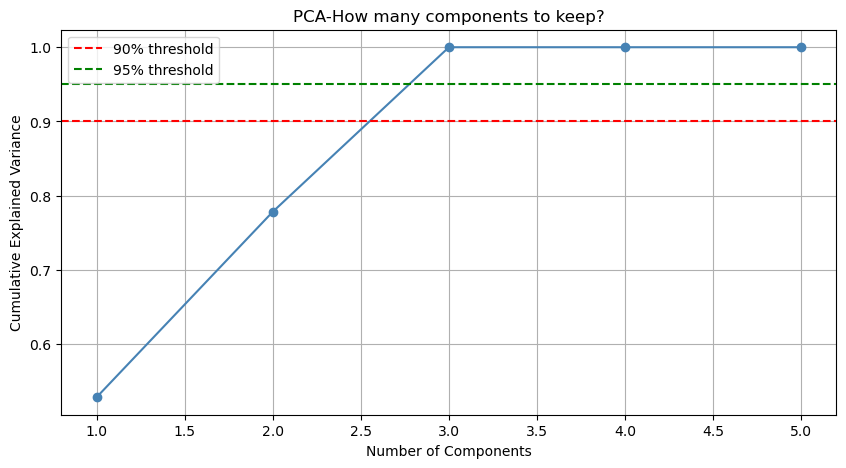

Number of components to retain 90% variance: 3
Number of components to retain 95% variance: 3


In [ ]:
#Finding the optimal Number of components(Elbow/Variance Plot)
pca_full=PCA()
pca_full.fit(x_scaled)

cumulative_variance=np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(10,5))
plt.plot(range(1,len(cumulative_variance)+1), cumulative_variance, marker='o',color='steelblue')
plt.axhline(y=0.90, color='red', linestyle='--',label='90% threshold')
plt.axhline(y=0.95, color='green', linestyle='--', label='95% threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA-How many components to keep?')
plt.legend()
plt.grid(True)
plt.show()

#Print how many components are needed to reach 90% and 95% variance
n_90=np.argmax(cumulative_variance>=0.90)+1
n_95=np.argmax(cumulative_variance>=0.95)+1
print(f"Number of components to retain 90% variance: {n_90}")
print(f"Number of components to retain 95% variance: {n_95}")


In [ ]:
pca=PCA(n_components=n_95)
x_pca=pca.fit_transform(x_scaled)

print(f"Original shape: {x_scaled.shape}")
print(f"Reduced shape: {x_pca.shape}" )

Original shape: (158985, 5)
Reduced shape: (158985, 3)


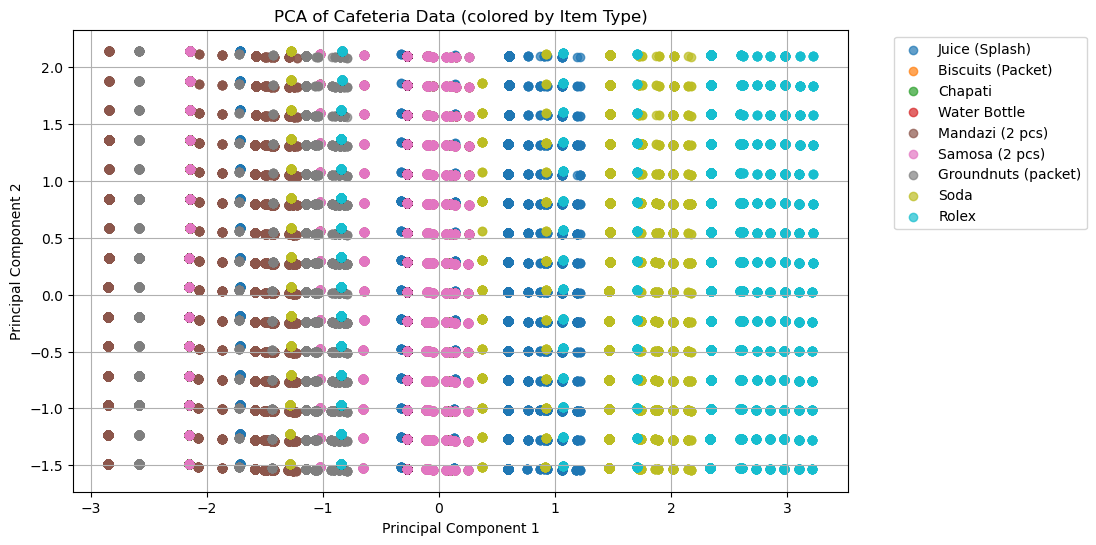

In [ ]:
#visualise in 2D (colur by meal type).Reduce to two components just for visualisation
pca_2d=PCA(n_components=2)
x_2d=pca_2d.fit_transform(x_scaled)
plt.figure(figsize=(10,6))
meals=df['Item'].unique()
colors=plt.cm.tab10(np.linspace(0,1,len(meals)))

for meal, color in zip(meals, colors):
    mask=df['Item']==meal
    plt.scatter(x_2d[mask,0], x_2d[mask,1], label=meal, alpha=0.7, color=color) 
    
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Cafeteria Data (colored by Item Type)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()


In [ ]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42,n_init=10)
df['Cluster']=kmeans.fit_predict(x_pca)
print(df['Cluster'].value_counts())

Cluster
0    102645
2     41656
1     14684
Name: count, dtype: int64


In [ ]:
# from sklearn.cluster import MiniBatchKMeans

# mbk = MiniBatchKMeans(n_clusters=3, random_state=42, batch_size=1000)
# cluster_labels = mbk.fit_predict(x_pca)
# df['Cluster'] = cluster_labels

# print(df['Cluster'].value_counts())

In [ ]:
cluster_0 = df[df['Cluster'] == 0]
cluster_1 = df[df['Cluster'] == 1]
cluster_2 = df[df['Cluster'] == 2]

In [ ]:
import pandas as pd

def make_time_series(cluster_df):
    cluster_df = cluster_df.copy()
    cluster_df['Date'] = pd.to_datetime(cluster_df['Date'])
    ts = cluster_df.groupby('Date')['Total_Amount_UGX'].sum().reset_index()
    ts = ts.set_index('Date').asfreq('D').fillna(0)  # fill missing days with 0
    return ts

ts_0 = make_time_series(cluster_0)
ts_1 = make_time_series(cluster_1)
ts_2 = make_time_series(cluster_2)

In [ ]:
from statsmodels.tsa.stattools import adfuller

def check_stationarity(ts, cluster_name):
    result = adfuller(ts['Total_Amount_UGX'])
    print(f"Cluster {cluster_name} — ADF Statistic: {result[0]:.4f}, p-value: {result[1]:.4f}")
    if result[1] < 0.05:
        print("  ✅ Stationary — d=0")
    else:
        print("  ⚠️  Non-stationary — use d=1 in SARIMA")

check_stationarity(ts_0, 0)
check_stationarity(ts_1, 1)
check_stationarity(ts_2, 2)

Cluster 0 — ADF Statistic: -2.7361, p-value: 0.0680
  ⚠️  Non-stationary — use d=1 in SARIMA
Cluster 1 — ADF Statistic: -2.9644, p-value: 0.0384
  ✅ Stationary — d=0
Cluster 2 — ADF Statistic: -2.7276, p-value: 0.0694
  ⚠️  Non-stationary — use d=1 in SARIMA


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')

def fit_sarima(ts, order=(1,1,1), seasonal_order=(1,1,1,7)):
    """
    order=(p,d,q) — AR, differencing, MA terms
    seasonal_order=(P,D,Q,s) — s=7 for weekly seasonality (daily data)
    """
    model = SARIMAX(ts['Total_Amount_UGX'],
                    order=order,
                    seasonal_order=seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False)
    result = model.fit(disp=False)
    print(result.summary())
    return result

model_0 = fit_sarima(ts_0)
model_1 = fit_sarima(ts_1)
model_2 = fit_sarima(ts_2)

                                     SARIMAX Results                                     
Dep. Variable:                  Total_Amount_UGX   No. Observations:                  700
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood               -8151.304
Date:                           Mon, 09 Mar 2026   AIC                          16312.608
Time:                                   14:56:53   BIC                          16335.241
Sample:                               02-01-2024   HQIC                         16321.367
                                    - 12-31-2025                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1388      0.078      1.780      0.075      -0.014       0.292
ma.L1         -0.6649      0.055    -12.160

In [ ]:
def forecast(model, ts, steps=30):
    forecast_obj = model.get_forecast(steps=steps)
    forecast_df = forecast_obj.summary_frame(alpha=0.05)  # 95% confidence interval
    return forecast_df

forecast_0 = forecast(model_0, ts_0, steps=30)
forecast_1 = forecast(model_1, ts_1, steps=30)
forecast_2 = forecast(model_2, ts_2, steps=30)

print(forecast_0[['mean', 'mean_ci_lower', 'mean_ci_upper']].head(10))

Total_Amount_UGX          mean  mean_ci_lower  mean_ci_upper
2026-01-01        42775.077595  -40952.776532  126502.931722
2026-01-02        50530.353775  -42125.110702  143185.818251
2026-01-03        29897.158178  -68651.706185  128446.022542
2026-01-04        18591.546253  -85247.118801  122430.211307
2026-01-05        48461.641896  -60374.765382  157298.049174
2026-01-06        50086.062321  -63523.765128  163695.889769
2026-01-07        48718.864382  -69471.128145  166908.856910
2026-01-08        39632.157349  -94018.404754  173282.719452
2026-01-09        49015.602767  -92563.594161  190594.799695
2026-01-10        27416.331458 -121002.672895  175835.335811


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate(model, ts, train_size=0.8):
    split = int(len(ts) * train_size)
    train, test = ts.iloc[:split], ts.iloc[split:]
    
    pred = model.predict(start=split, end=len(ts)-1)
    mae = mean_absolute_error(test, pred)
    rmse = np.sqrt(mean_squared_error(test, pred))
    print(f"MAE: {mae:.2f} | RMSE: {rmse:.2f}")

evaluate(model_0, ts_0)
evaluate(model_1, ts_1)
evaluate(model_2, ts_2)

MAE: 23247.34 | RMSE: 32298.09
MAE: 3986.98 | RMSE: 5064.02
MAE: 29845.20 | RMSE: 39889.45


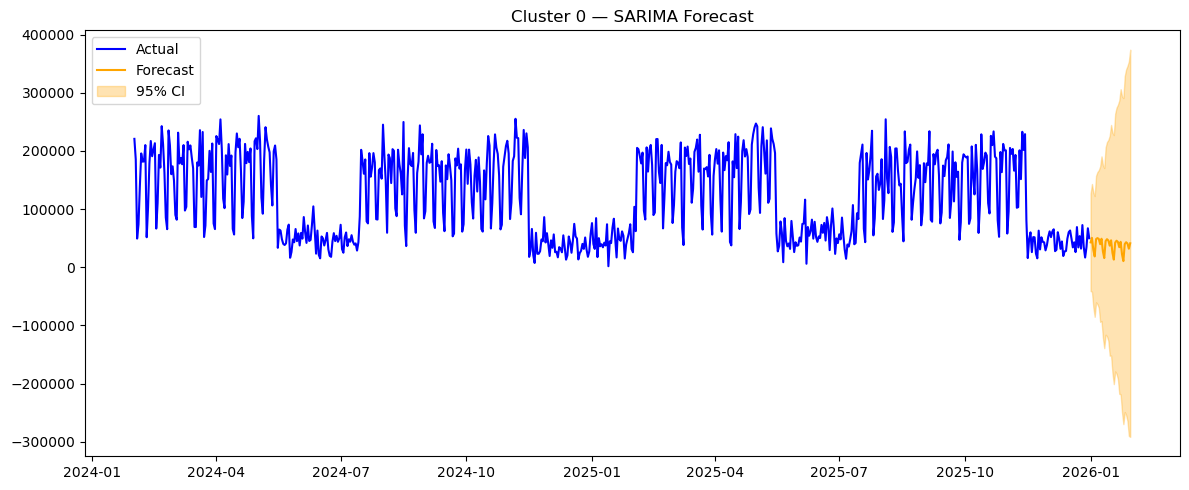

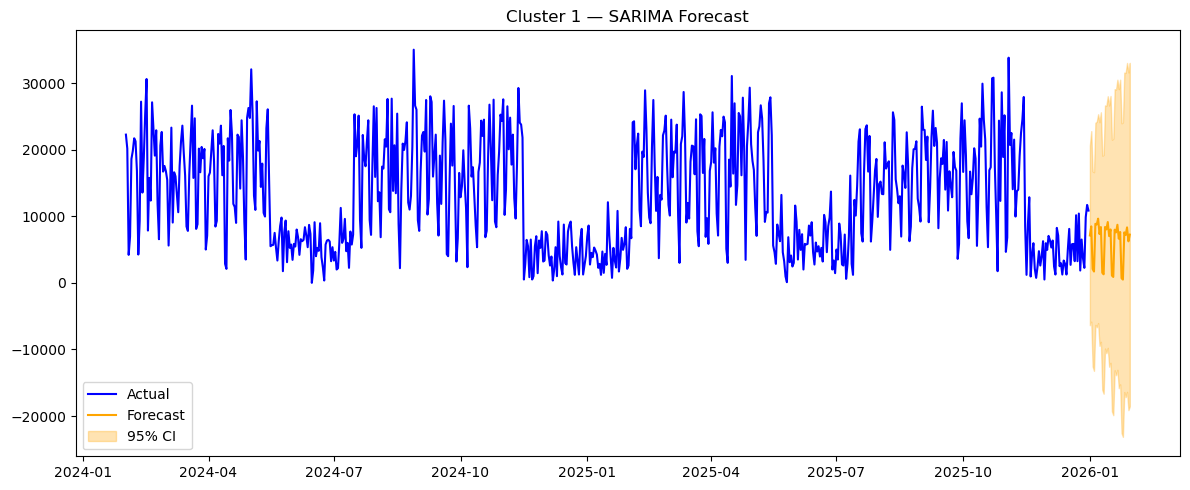

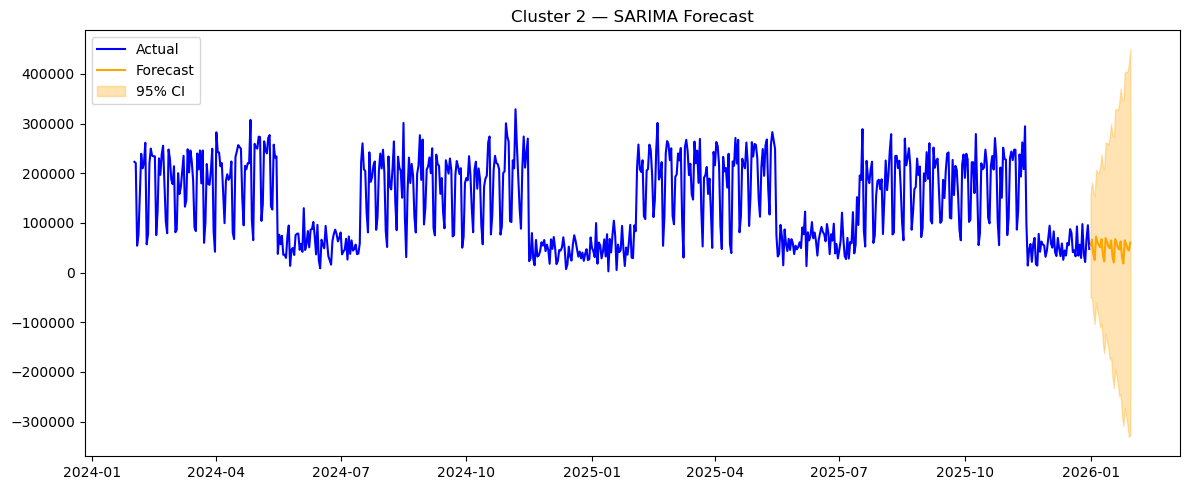

In [ ]:
import matplotlib.pyplot as plt

def plot_forecast(ts, forecast_df, cluster_name):
    plt.figure(figsize=(12, 5))
    plt.plot(ts, label='Actual', color='blue')
    plt.plot(forecast_df['mean'], label='Forecast', color='orange')
    plt.fill_between(forecast_df.index,
                     forecast_df['mean_ci_lower'],
                     forecast_df['mean_ci_upper'],
                     alpha=0.3, color='orange', label='95% CI')
    plt.title(f'Cluster {cluster_name} — SARIMA Forecast')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_forecast(ts_0, forecast_0, 0)
plot_forecast(ts_1, forecast_1, 1)
plot_forecast(ts_2, forecast_2, 2)

In [ ]:
# ── XAI 1 & 2: PCA Loadings + Biplot ────────────────────────
# Answers: "Which original features make up each principal component?"

# 1. Loadings heatmap — which features dominate PC1, PC2, PC3?
loadings = pd.DataFrame(
    pca.components_.T,
    index   = numeric_cols,
    columns = [f"PC{i+1}" for i in range(pca.n_components_)]
)

fig, ax = plt.subplots(figsize=(12, 7))
im = ax.imshow(loadings.iloc[:, :6].values, cmap="RdBu_r",
               vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(min(6, pca.n_components_)))
ax.set_xticklabels([f"PC{i+1}" for i in range(min(6, pca.n_components_))])
ax.set_yticks(range(len(numeric_cols)))
ax.set_yticklabels(numeric_cols, fontsize=9)
plt.colorbar(im, ax=ax, label="Loading weight (-1 to +1)")
ax.set_title("PCA Component Loadings — which features drive each component?",
             fontsize=12)
for i in range(loadings.shape[0]):
    for j in range(min(6, pca.n_components_)):
        ax.text(j, i, f"{loadings.iloc[i, j]:.2f}",
                ha="center", va="center", fontsize=7,
                color="white" if abs(loadings.iloc[i, j]) > 0.5 else "black")
plt.tight_layout()
plt.savefig("pca_loadings_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 5 features contributing to PC1 (most important component):")
print(loadings["PC1"].abs().sort_values(ascending=False).head(5))
print("\nTop 5 features contributing to PC2:")
print(loadings["PC2"].abs().sort_values(ascending=False).head(5))

# 2. Biplot — shows both samples and feature arrows in PCA space
pca_2d = PCA(n_components=2)
x_2d   = pca_2d.fit_transform(x_scaled)
load_2d = pca_2d.components_.T  # shape: (n_features, 2)

fig, ax = plt.subplots(figsize=(10, 7))
clusters = df["Cluster"].values
colors_c = ["#2196F3", "#FF5722", "#4CAF50"]
for c, col in zip([0, 1, 2], colors_c):
    mask = clusters == c
    ax.scatter(x_2d[mask, 0], x_2d[mask, 1],
               c=col, alpha=0.3, s=10, label=f"Cluster {c}")

# Draw feature arrows
scale = 3
for i, feat in enumerate(numeric_cols):
    ax.annotate("", xy=(load_2d[i, 0]*scale, load_2d[i, 1]*scale),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", color="red", lw=1.2))
    ax.text(load_2d[i, 0]*scale*1.1, load_2d[i, 1]*scale*1.1,
            feat, fontsize=8, color="darkred")

ax.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.set_title("PCA Biplot — samples coloured by cluster, arrows = feature directions")
ax.axhline(0, color="gray", lw=0.5, ls="--")
ax.axvline(0, color="gray", lw=0.5, ls="--")
ax.legend()
plt.tight_layout()
plt.savefig("pca_biplot.png", dpi=150, bbox_inches="tight")
plt.show()
print("PCA XAI plots saved.")

In [ ]:
# ── XAI 6: SARIMA Residual Diagnostics ──────────────────────
# Answers: "Can I trust this model? Are its assumptions met?"
# statsmodels has a built-in 4-panel diagnostic plot

for cluster_id, model in zip([0, 1, 2], [model_0, model_1, model_2]):
    fig = model.plot_diagnostics(figsize=(14, 8))
    fig.suptitle(
        f"SARIMA Residual Diagnostics — Cluster {cluster_id}\n"
        "Top-left: residuals random? | Top-right: histogram normal?\n"
        "Bottom-left: Q-Q line straight? | Bottom-right: no autocorrelation?",
        fontsize=10
    )
    plt.tight_layout()
    plt.savefig(f"sarima_residuals_cluster{cluster_id}.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\nCluster {cluster_id} — Ljung-Box test (residuals independent?):")
    from statsmodels.stats.diagnostic import acorr_ljungbox
    lb = acorr_ljungbox(model.resid, lags=[7, 14], return_df=True)
    print(lb)
    print("p-value > 0.05 = residuals are white noise = good model fit")

NameError: name 'model_0' is not defined

In [ ]:
# ── XAI 7: SARIMA Parameter Significance ────────────────────
# Answers: "Which AR/MA terms are statistically significant?"

for cluster_id, model in zip([0, 1, 2], [model_0, model_1, model_2]):
    params = model.summary().tables[1]
    param_df = pd.read_html(params.as_html(), header=0)[0]
    param_df.columns = ["Parameter", "Coefficient", "Std Error",
                        "z-score", "p-value", "CI Lower", "CI Upper"]

    fig, ax = plt.subplots(figsize=(11, max(3, len(param_df)*0.5+1)))
    ax.axis("off")
    tbl = ax.table(
        cellText  = param_df.values,
        colLabels = param_df.columns,
        cellLoc   = "center", loc="center"
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1, 1.5)
    for (row, col), cell in tbl.get_celld().items():
        if row == 0:
            cell.set_facecolor("#1B3A6B")
            cell.set_text_props(color="white", fontweight="bold")
        elif row > 0:
            try:
                pval = float(param_df.iloc[row-1]["p-value"])
                cell.set_facecolor("#D5F5E3" if pval < 0.05 else "#FDECEA")
            except:
                pass
    ax.set_title(
        f"Cluster {cluster_id} — SARIMA Parameters\n"
        "Green = statistically significant (p<0.05) | Red = not significant",
        fontsize=11, pad=20
    )
    plt.tight_layout()
    plt.savefig(f"sarima_params_cluster{cluster_id}.png",
                dpi=150, bbox_inches="tight")
    plt.show()

NameError: name 'model_0' is not defined